In [7]:
# 💡 Summary in 1 sentence each:

# RMSE: Focus on large errors, lower = better.

# MAE: Average error, lower = better.

# MAPE: Percentage error, lower = better.

# R²: How well model explains variation, closer to 1 = better.

In [8]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [9]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import requests

In [10]:
# ================= CONFIG =================
BASE_DIR   = "../STOCK-EVALUATION-DATA-FIGURE/"
MODELS_DIR = "../DATA-HTML-STOCK/Models"
TIME_STEPS = 60
DROPOUT    = 0.2
NEURONS    = 64
LR         = 0.001
BATCH_SIZE = 32
EPOCHS     = 100
PATIENCE   = 15
os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# ================= DATA =================
companyDetails = pd.read_csv("../DATA-HTML-STOCK/NEPSECompany/NEPSECompanyExtractor.csv")
symbols = companyDetails["Symbol"]
stock_ignored  = ["CORBLP", "GFCLPO", "HBLPO", "LFCPO", "SBIPO", "GABLPO", "AMFIPO", "NMLBS", "ILFCPO", "JSLBBP"]
stock_no_news  = ["HATHPO", "BUDBLP", "CFCLPO", "CORBLP", "EBLPO", "HAMROP", "HGIPO", "JFLPO", "JBNLPO",
                  "KADBLP", "KNBLPO", "CEFLPO", "LBLPO", "MFILPO", "MIDBLP", "NBBLPO", "NABBPO", "NBBPO",
                  "PFLPO", "PRINPO", "PURBLP", "SBBLJP", "SIFCPO", "SILPO", "SMFDBP", "SYFLPO", "TNBLPO",
                  "TDBLPO", "UFLPO", "WDBLPO", "WMBFPO", "HLBSLP"]
needCompareModel = ["ADBL", "BARUN", "API", "NABIL", "NICA", "NTC"]

In [11]:
# ================= FUNCTIONS =================
def create_sequences(dataset, time_steps=60):
    """
    Standard sequence builder. Dataset must already include TIME_STEPS
    look-back rows from the previous split (overlap window) so that the
    very first prediction is still a full window.
    """
    X, y = [], []
    for i in range(time_steps, len(dataset)):
        X.append(dataset[i - time_steps:i])
        y.append(dataset[i, 0])   # predict Close only
    return np.array(X), np.array(y)


def build_model(time_steps, n_features):
    model = Sequential([
        LSTM(NEURONS, return_sequences=True, input_shape=(time_steps, n_features)),
        Dropout(DROPOUT),
        LSTM(NEURONS),
        Dropout(DROPOUT),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=LR), loss='mean_squared_error')
    model.summary()
    return model


def naive_baseline_mape(y_actual):
    """Predict today = yesterday. Lower bound for what LSTM must beat."""
    naive_pred = y_actual[:-1]
    actual     = y_actual[1:]
    return np.mean(np.abs((actual - naive_pred) / actual)) * 100



===== Processing ADBL =====


/mnt/d/spa/python/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 60, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,241 (196.25 KB)

 Trainable params: 50,241 (196.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 0.0067 - val_loss: 2.0248e-04
Epoch 2/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0019 - val_loss: 2.2291e-04
Epoch 3/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0018 - val_loss: 1.9284e-04
Epoch 4/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0016 - val_loss: 2.9082e-04
Epoch 5/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0015 - val_loss: 3.4851e-04
Epoch 6/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0014 - val_loss: 3.5116e-04
Epoch 7/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0014 - val_loss: 2.0477e-04
Epoch 8/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0013 - val_loss: 1.9367e-04
Epoch 9/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0013 - val_loss: 1.9799e-04
Epoch 10/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0012 - val_loss: 2.6422e-04
Epoch 11/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0010 - val_loss: 4.0214e-04
Epoch 1

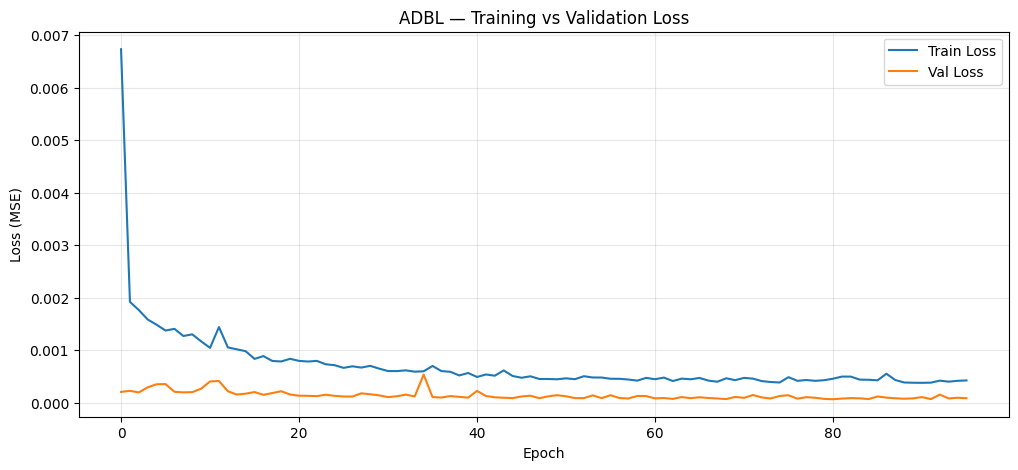

  RMSE: 5.86, MAE: 3.96, MAPE: 1.30%, R²: 0.9824, Beats naive? NO ✗


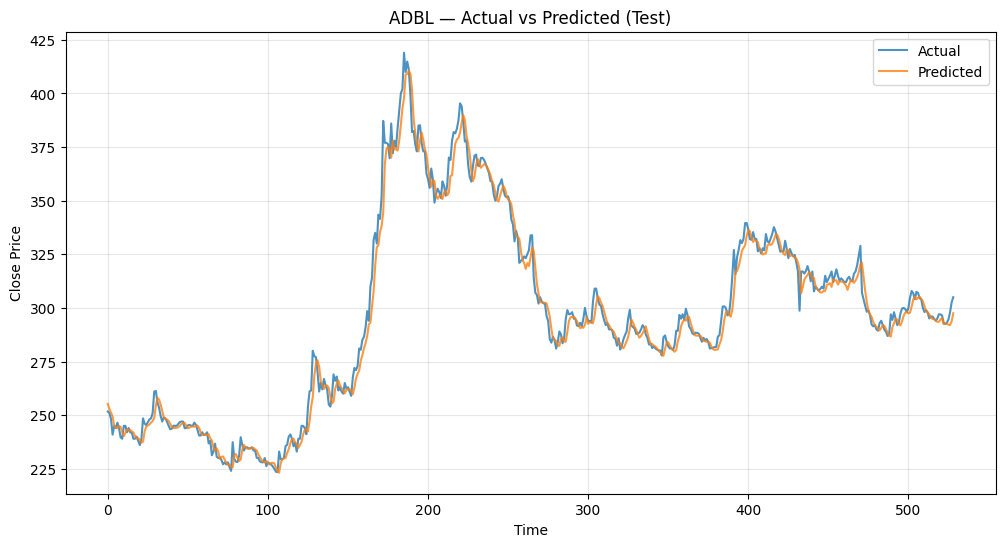

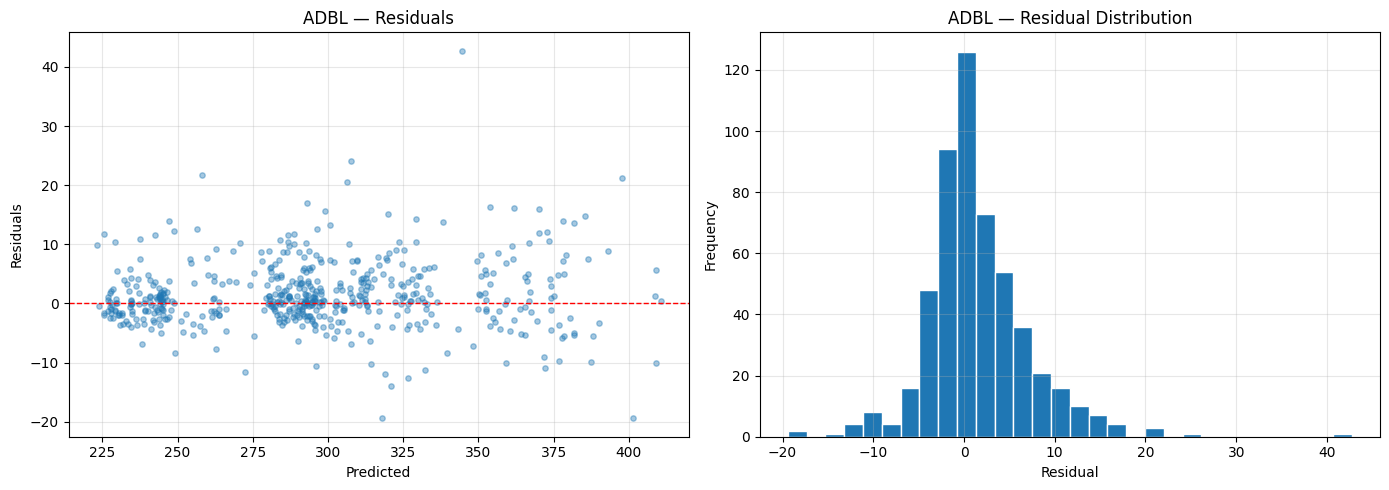

  Tomorrow forecast: NPR 301.15 (current: NPR 305.00)
  Done — ADBL

===== Processing API =====


/mnt/d/spa/python/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 60, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,241 (196.25 KB)

 Trainable params: 50,241 (196.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - loss: 0.0165 - val_loss: 2.9822e-04
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0035 - val_loss: 2.2099e-04
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0031 - val_loss: 2.0841e-04
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0026 - val_loss: 2.4513e-04
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0027 - val_loss: 2.5888e-04
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0024 - val_loss: 1.9372e-04
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0024 - val_loss: 4.7321e-04
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0023 - val_loss: 1.8763e-04
Epoch 9/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0021 - val_loss: 3.3106e-04
Epoch 10/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0019 - val_loss: 4.3499e-04
Epoch 11/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0019 - val_loss: 2.4195e-04
Epoch 1

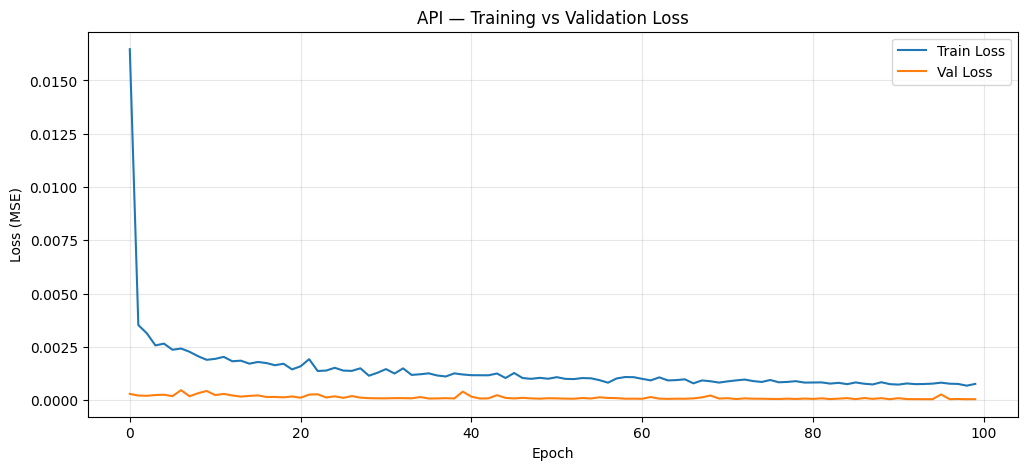

  RMSE: 7.03, MAE: 4.90, MAPE: 1.66%, R²: 0.8612, Beats naive? NO ✗


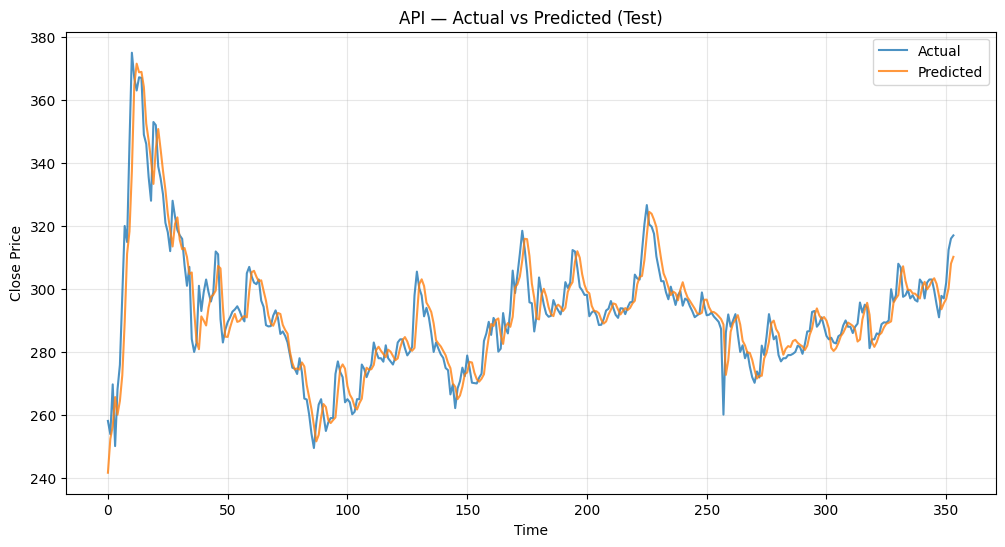

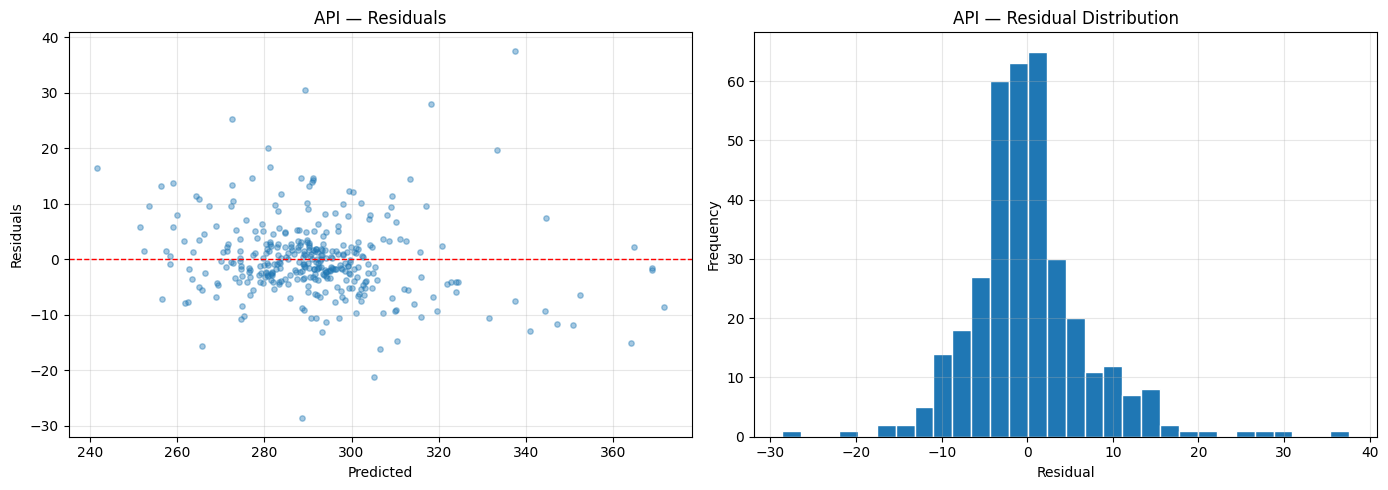

  Tomorrow forecast: NPR 312.46 (current: NPR 317.00)
  Done — API

===== Processing HATH =====

===== Processing HATHPO =====

===== Processing AKPL =====

===== Processing AHPC =====

===== Processing ALICL =====

===== Processing ALICLP =====

===== Processing BOKL =====

===== Processing BOKLPO =====

===== Processing BARUN =====


/mnt/d/spa/python/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                  │ (None, 60, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,241 (196.25 KB)

 Trainable params: 50,241 (196.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0129 - val_loss: 6.4929e-04
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0034 - val_loss: 5.5500e-04
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0033 - val_loss: 7.9511e-04
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0026 - val_loss: 6.4595e-04
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0026 - val_loss: 4.6545e-04
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0023 - val_loss: 4.2579e-04
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0025 - val_loss: 4.8264e-04
Epoch 8/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0023 - val_loss: 4.0830e-04
Epoch 9/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0019 - val_loss: 3.5018e-04
Epoch 10/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0022 - val_loss: 3.3612e-04
Epoch 11/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0018 - val_loss: 3.9665e-04
Epoch 12

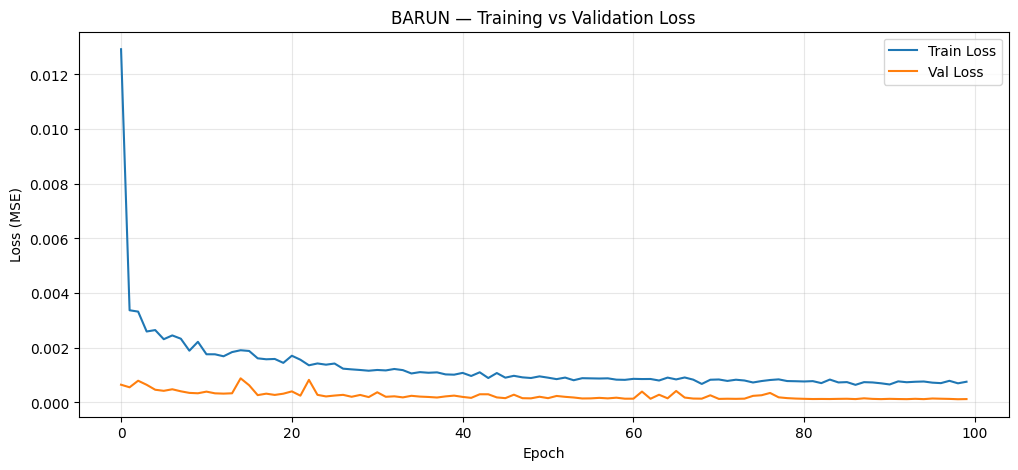

  RMSE: 12.89, MAE: 7.90, MAPE: 2.00%, R²: 0.9697, Beats naive? YES ✓


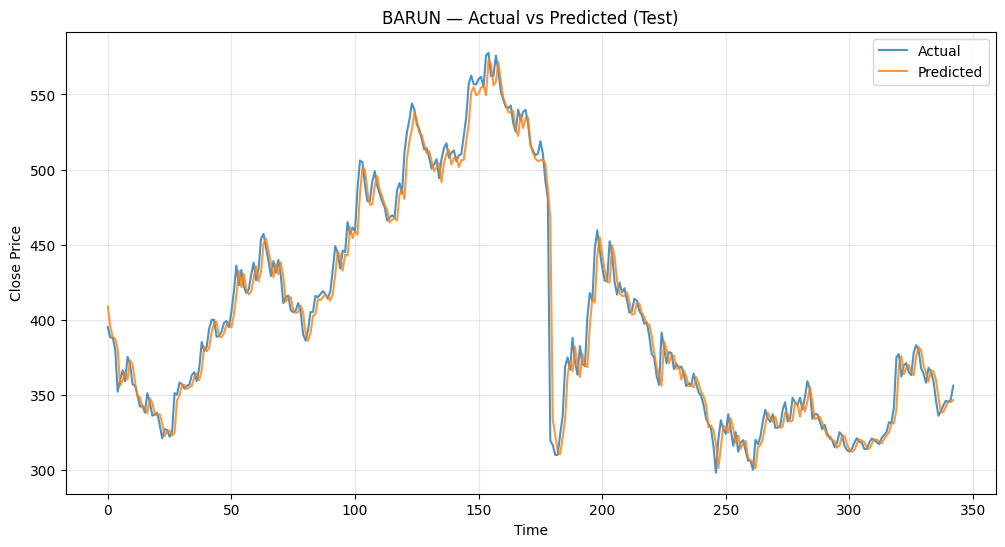

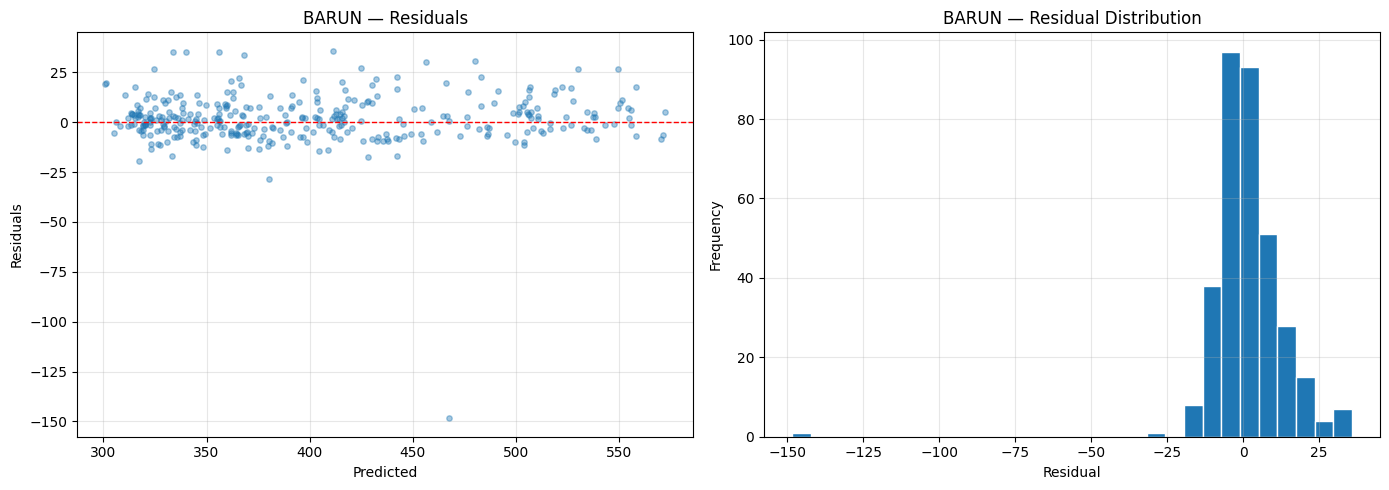

  Tomorrow forecast: NPR 354.02 (current: NPR 356.00)
  Done — BARUN

===== Processing BFC =====

===== Processing BFCPO =====

===== Processing BHBL =====

===== Processing BHBLPO =====

===== Processing BBC =====

===== Processing BNT =====

===== Processing BNL =====

===== Processing BUDBL =====

===== Processing BUDBLP =====

===== Processing BPCL =====

===== Processing CFCL =====

===== Processing CFCLPO =====

===== Processing CCBL =====

===== Processing CCBLPO =====

===== Processing CBBL =====

===== Processing CHL =====

===== Processing CHCL =====

===== Processing CIT =====

===== Processing CZBIL =====

===== Processing CZBILP =====

===== Processing CBL =====

===== Processing CBLPO =====

===== Processing HLBSL =====

===== Processing CORBL =====

===== Processing CORBLP =====

===== Processing DDBL =====

===== Processing DDBLPO =====

===== Processing DBBL =====

===== Processing DBBLPO =====

===== Processing DHPL =====

===== Processing EBL =====

===== Processing 

/mnt/d/spa/python/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_18 (LSTM)                  │ (None, 60, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,241 (196.25 KB)

 Trainable params: 50,241 (196.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - loss: 0.0103 - val_loss: 5.4365e-04
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0034 - val_loss: 5.4546e-04
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0032 - val_loss: 5.1991e-04
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0026 - val_loss: 4.9255e-04
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0025 - val_loss: 5.0988e-04
Epoch 6/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0025 - val_loss: 4.9059e-04
Epoch 7/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0023 - val_loss: 5.3402e-04
Epoch 8/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0022 - val_loss: 5.4829e-04
Epoch 9/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0022 - val_loss: 6.9061e-04
Epoch 10/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0022 - val_loss: 4.3274e-04
Epoch 11/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0021 - val_loss: 3.9868e-04
Epoch 1

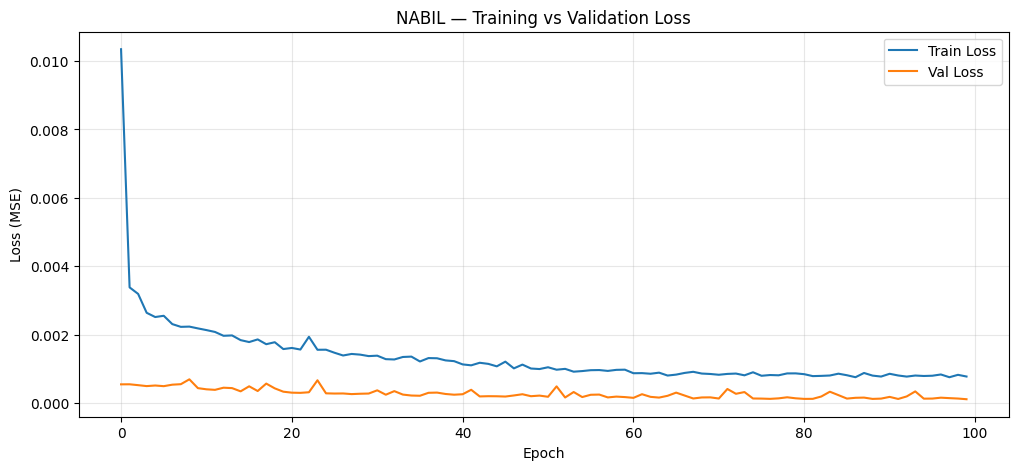

  RMSE: 11.24, MAE: 9.55, MAPE: 1.91%, R²: 0.9402, Beats naive? NO ✗


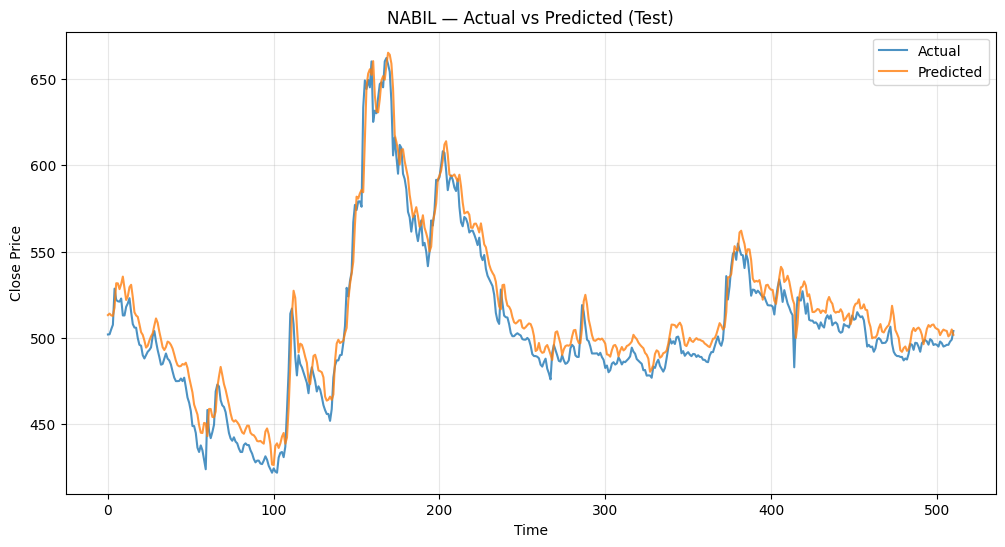

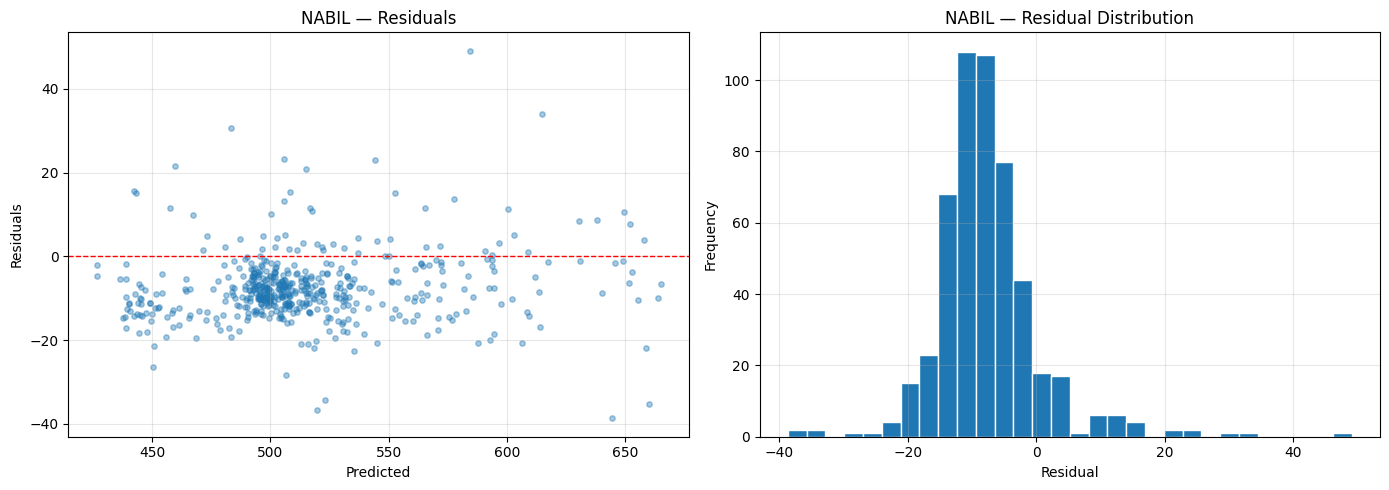

  Tomorrow forecast: NPR 507.26 (current: NPR 504.00)
  Done — NABIL

===== Processing NABILP =====

===== Processing NEF =====

===== Processing NBBL =====

===== Processing NBBLPO =====

===== Processing NBSL =====

===== Processing NHPC =====

===== Processing NLICL =====

===== Processing NLICLP =====

===== Processing NMLBS =====

===== Processing NNLB =====

===== Processing NIL =====

===== Processing NILPO =====

===== Processing NABB =====

===== Processing NABBPO =====

===== Processing NBB =====

===== Processing NBBPO =====

===== Processing NBL =====

===== Processing NCDB =====

===== Processing NCDBPO =====

===== Processing NCCB =====

===== Processing NCCBPO =====

===== Processing NTC =====


/mnt/d/spa/python/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_20 (LSTM)                  │ (None, 60, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,241 (196.25 KB)

 Trainable params: 50,241 (196.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step - loss: 0.0129 - val_loss: 0.0048
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0019 - val_loss: 0.0042
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 0.0019 - val_loss: 0.0038
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0016 - val_loss: 0.0037
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0017 - val_loss: 0.0031
Epoch 6/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0014 - val_loss: 0.0029
Epoch 7/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0018 - val_loss: 0.0028
Epoch 8/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0013 - val_loss: 0.0030
Epoch 9/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0013 - val_loss: 0.0024
Epoch 10/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0012 - val_loss: 0.0023
Epoch 11/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0011 - val_loss: 0.0023
Epoch 12/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/ste

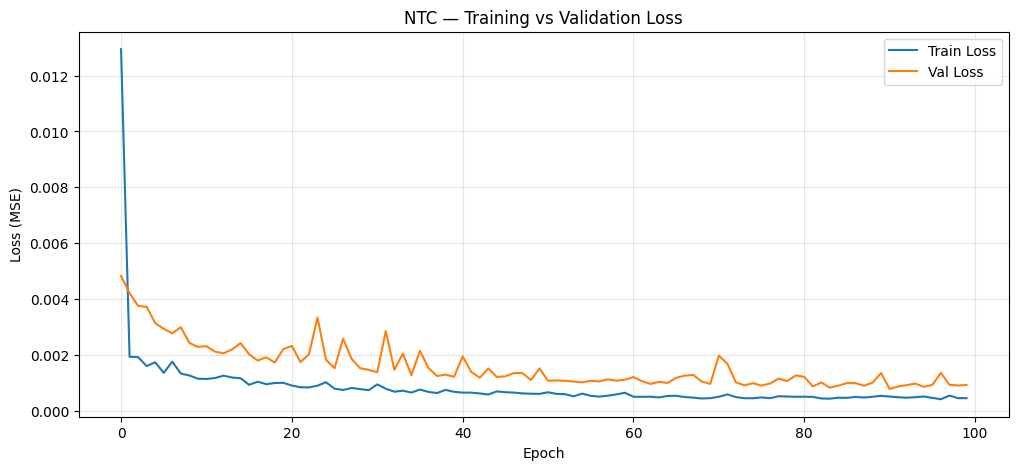

  RMSE: 13.99, MAE: 9.73, MAPE: 1.07%, R²: 0.9411, Beats naive? NO ✗


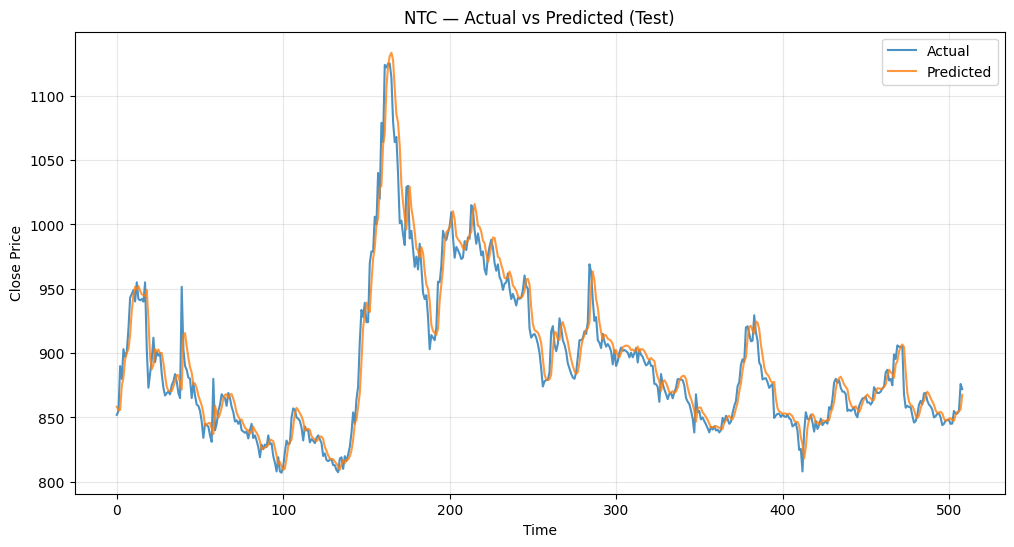

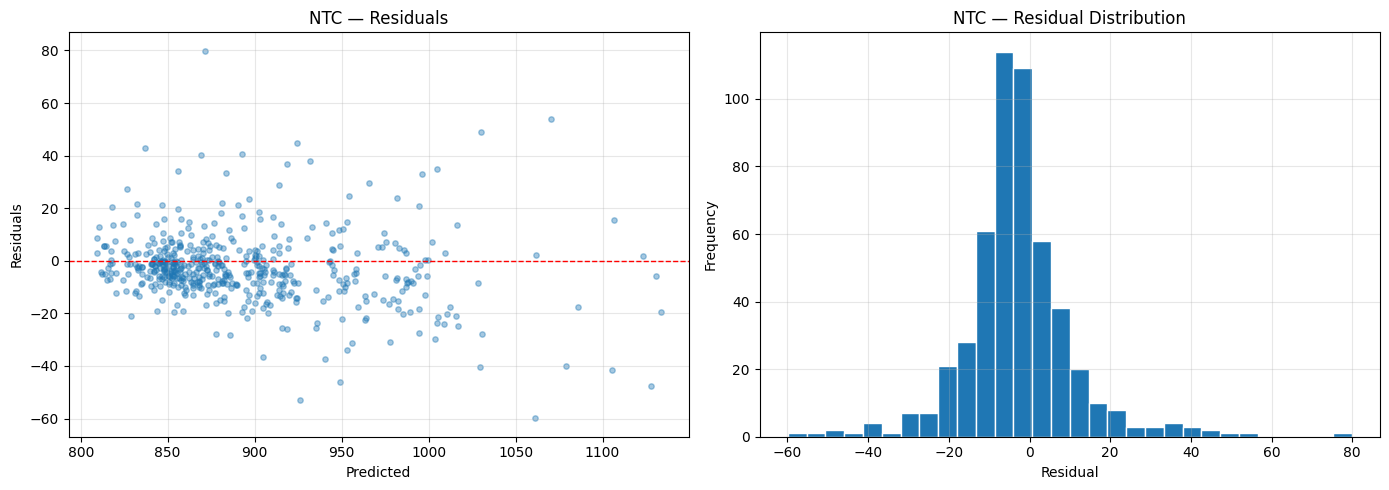

  Tomorrow forecast: NPR 872.78 (current: NPR 872.00)
  Done — NTC

===== Processing GBLBS =====

===== Processing GBLBSP =====

===== Processing NHDL =====

===== Processing NICL =====

===== Processing NIB =====

===== Processing NIBPO =====

===== Processing NLIC =====

===== Processing NLICP =====

===== Processing SBI =====

===== Processing SBIPO =====

===== Processing NLBBL =====

===== Processing NGPL =====

===== Processing NIBLPF =====

===== Processing NIBSF1 =====

===== Processing NICA =====


/mnt/d/spa/python/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_22 (LSTM)                  │ (None, 60, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,241 (196.25 KB)

 Trainable params: 50,241 (196.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - loss: 0.0182 - val_loss: 0.0027
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0051 - val_loss: 0.0022
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0044 - val_loss: 0.0031
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0037 - val_loss: 0.0025
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0043 - val_loss: 0.0018
Epoch 6/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0034 - val_loss: 0.0014
Epoch 7/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0032 - val_loss: 0.0012
Epoch 8/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0029 - val_loss: 0.0012
Epoch 9/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0031 - val_loss: 0.0011
Epoch 10/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0028 - val_loss: 0.0015
Epoch 11/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0031 - val_loss: 0.0012
Epoch 12/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step

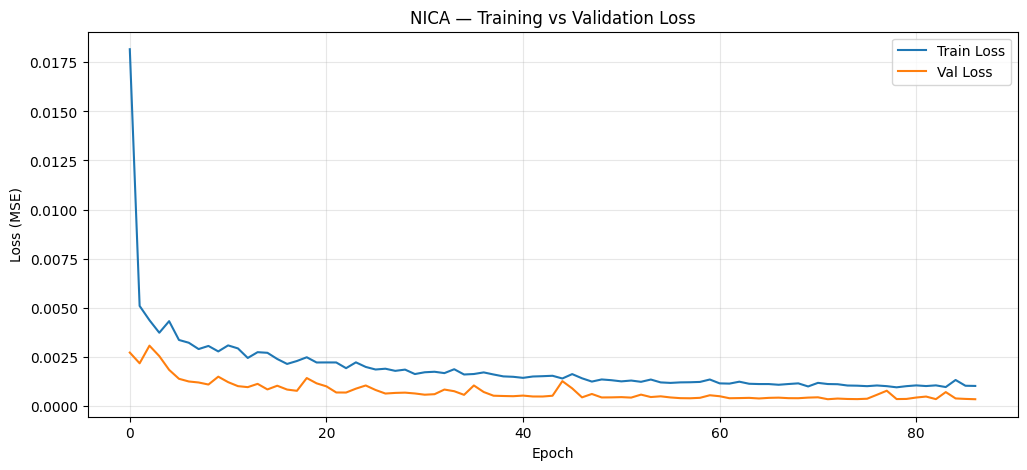

  RMSE: 11.01, MAE: 7.66, MAPE: 1.96%, R²: 0.9598, Beats naive? NO ✗


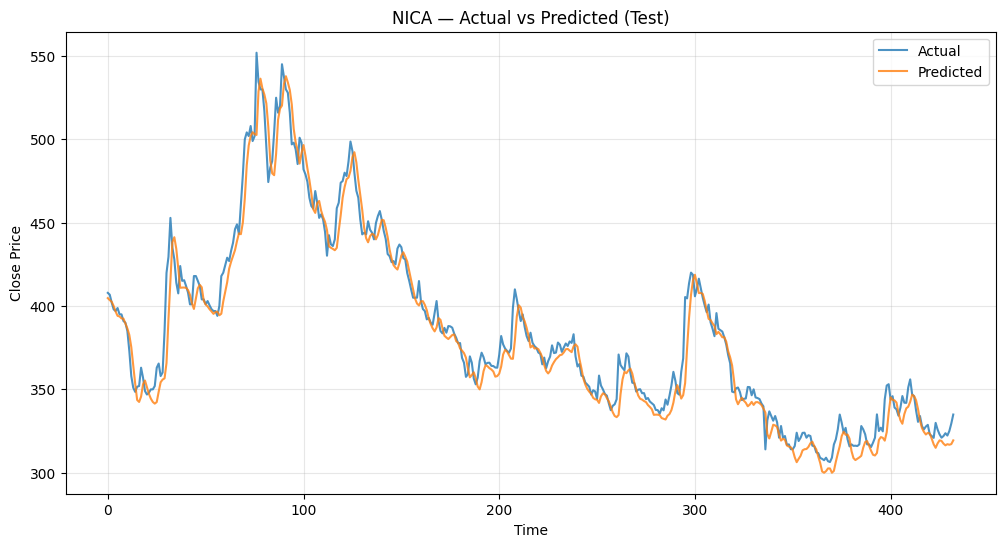

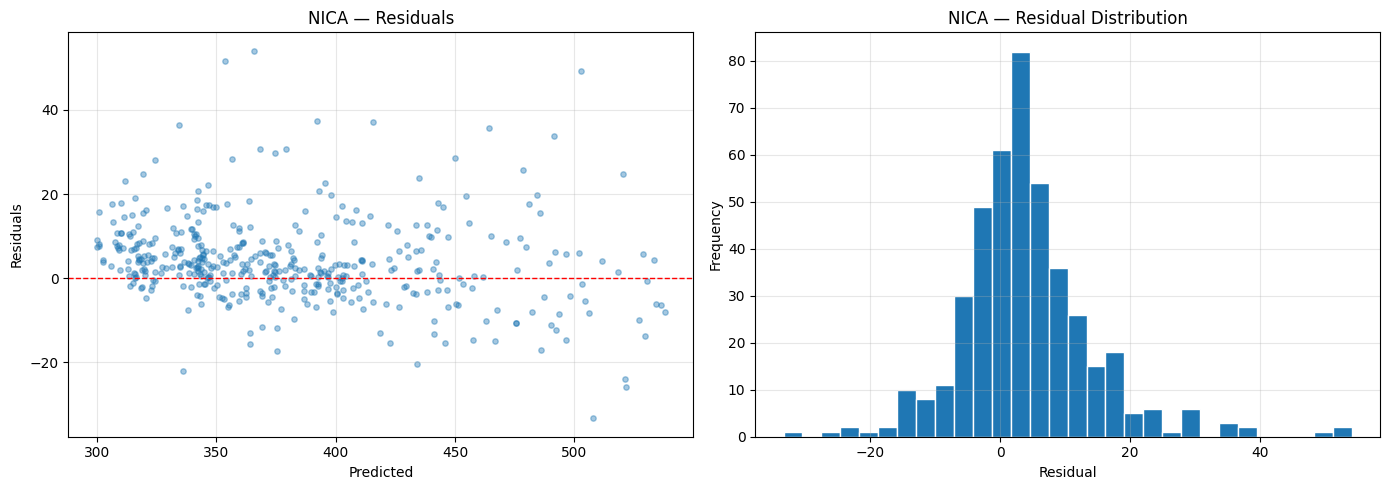

  Tomorrow forecast: NPR 323.67 (current: NPR 334.90)
  Done — NICA

===== Processing NICAP =====

===== Processing NIDC =====

===== Processing NUBL =====

===== Processing NLG =====

===== Processing NMB =====

===== Processing NMBPO =====

===== Processing NMBMF =====

===== Processing NMBSF1 =====

===== Processing ODBL =====

===== Processing ODBLPO =====

===== Processing OHL =====

===== Processing PFL =====

===== Processing PFLPO =====

===== Processing PRVU =====

===== Processing PRVUPO =====

===== Processing PRIN =====

===== Processing PRINPO =====

===== Processing PIC =====

===== Processing PCBL =====

===== Processing PCBLP =====

===== Processing PLIC =====

===== Processing PLICPO =====

===== Processing PROFL =====

===== Processing PROFLP =====

===== Processing PICL =====

===== Processing PICLPO =====

===== Processing PURBL =====

===== Processing PURBLP =====

===== Processing RBCL =====

===== Processing RBCLPO =====

===== Processing RLFL =====

===== Proces

In [12]:
# ================= MAIN LOOP =================
for symbol in symbols:
    print(f"\n===== Processing {symbol} =====")
    if symbol not in needCompareModel:
        continue
    if symbol in stock_ignored:
        continue

    symbol_path = os.path.join(BASE_DIR, symbol)
    os.makedirs(symbol_path, exist_ok=True)

    stock_path = f"../DATA-HTML-STOCK/NEPSEDATA/{symbol}.csv"
    final_path = f"../DATA-HTML-STOCK/FinalDataSet/{symbol}.csv"
    model_path = os.path.join(MODELS_DIR, f"{symbol}_lstm.h5")

    if not os.path.exists(stock_path) or not os.path.exists(final_path):
        print(f"  {symbol}: missing data files, skipping.")
        continue

    # ===== LOAD & CLEAN STOCK =====
    stock_df = pd.read_csv(stock_path)
    stock_df = stock_df[['Date', 'Open', 'High', 'Low', 'Close', 'Qty']].dropna()
    stock_df[['Open', 'High', 'Low', 'Close', 'Qty']] = stock_df[['Open', 'High', 'Low', 'Close', 'Qty']].replace(',', '', regex=True).astype(float)
    stock_df['Date'] = pd.to_datetime(stock_df['Date'])
    stock_df = stock_df.sort_values("Date").reset_index(drop=True)  # OLD → NEW

    # ===== LOAD SENTIMENT =====
    sentiment_df = pd.read_csv(final_path)
    sentiment_df = sentiment_df[['Date_Stock', 'Decayed_Sentiment']]
    sentiment_df['Date_Stock'] = pd.to_datetime(sentiment_df['Date_Stock'])

    # ===== MERGE =====
    data = pd.merge(stock_df, sentiment_df, left_on='Date', right_on='Date_Stock', how='left')
    data['Decayed_Sentiment'] = 0.0 if symbol in stock_no_news else data['Decayed_Sentiment'].fillna(0.0)
    data = data.dropna(subset=['Close'])
    data = data.sort_values("Date").reset_index(drop=True)

    if len(data) < TIME_STEPS + 30:
        print(f"  {symbol}: not enough data ({len(data)} rows), skipping.")
        continue

    current_price = data['Close'].iloc[-1]
    values = data[['Close', 'Decayed_Sentiment']].values

    # ===== SCALE (fit ONLY on TRAIN) =====
    train_size = int(0.7 * len(values))
    val_size   = int(0.15 * len(values))

    scaler = MinMaxScaler()
    scaler.fit(values[:train_size])
    scaled_all = scaler.transform(values)

    train_data = scaled_all[:train_size]
    val_data   = scaled_all[train_size - TIME_STEPS : train_size + val_size]
    test_data  = scaled_all[train_size + val_size - TIME_STEPS :]

    # ===== CREATE SEQUENCES =====
    X_train, y_train = create_sequences(train_data, TIME_STEPS)
    X_val,   y_val   = create_sequences(val_data, TIME_STEPS)
    X_test,  y_test  = create_sequences(test_data, TIME_STEPS)

    if len(X_train) == 0 or len(X_test) == 0:
        print(f"  {symbol}: insufficient sequences, skipping.")
        continue

    # ===== BUILD OR LOAD MODEL =====
    if os.path.exists(model_path):
        model = load_model(model_path)
        history = None
        print(f"  Loaded cached model from {model_path}")
    else:
        model = build_model(TIME_STEPS, 2)
        early_stop = EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True)
        history = model.fit(
            X_train, y_train,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            validation_data=(X_val, y_val),
            callbacks=[early_stop],
            verbose=1
        )
        # ===== TRAINING LOSS PLOT =====
        plt.figure(figsize=(12, 5))
        plt.plot(history.history['loss'], label='Train Loss')
        plt.plot(history.history['val_loss'], label='Val Loss')
        plt.xlabel('Epoch'); plt.ylabel('Loss (MSE)')
        plt.title(f"{symbol} — Training vs Validation Loss")
        plt.legend(); plt.grid(True, alpha=0.3)
        plt.savefig(os.path.join(symbol_path, "training_loss.png"), dpi=150)
        plt.show(); plt.close()
        model.save(model_path)

    # ===== PREDICTION =====
    predictions = model.predict(X_test, verbose=0)
    n = len(predictions)
    dummy_pred = np.zeros((n, 2)); dummy_pred[:, 0] = predictions.flatten()
    dummy_y    = np.zeros((n, 2)); dummy_y[:, 0] = y_test.flatten()
    predictions_actual = scaler.inverse_transform(dummy_pred)[:, 0]
    y_test_actual      = scaler.inverse_transform(dummy_y)[:, 0]

    # ===== METRICS =====
    mse  = mean_squared_error(y_test_actual, predictions_actual)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test_actual, predictions_actual)
    mape = np.mean(np.abs((y_test_actual - predictions_actual) / y_test_actual)) * 100
    r2   = r2_score(y_test_actual, predictions_actual)
    naive_mape = naive_baseline_mape(y_test_actual)
    beat_naive = "YES ✓" if mape < naive_mape else "NO ✗"

    print(f"  RMSE: {rmse:.2f}, MAE: {mae:.2f}, MAPE: {mape:.2f}%, R²: {r2:.4f}, Beats naive? {beat_naive}")

    # ===== PLOTS =====
    # Actual vs Predicted
    plt.figure(figsize=(12,6))
    plt.plot(y_test_actual, label='Actual', alpha=0.8)
    plt.plot(predictions_actual, label='Predicted', alpha=0.8)
    plt.xlabel("Time"); plt.ylabel("Close Price")
    plt.title(f"{symbol} — Actual vs Predicted (Test)")
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(symbol_path, "prediction.png"), dpi=150)
    plt.show(); plt.close()

    # Residuals
    residuals = y_test_actual - predictions_actual
    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    axes[0].scatter(predictions_actual, residuals, alpha=0.4, s=15)
    axes[0].axhline(0, linestyle='--', color='red', linewidth=1)
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Residuals'); axes[0].set_title(f"{symbol} — Residuals"); axes[0].grid(True, alpha=0.3)
    axes[1].hist(residuals, bins=30, edgecolor='white')
    axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Frequency'); axes[1].set_title(f"{symbol} — Residual Distribution"); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(symbol_path, "residuals.png"), dpi=150)
    plt.show(); plt.close()

    # ===== TOMORROW FORECAST =====
    last_window     = scaled_all[-TIME_STEPS:].reshape(1, TIME_STEPS, 2)
    tomorrow_scaled = model.predict(last_window, verbose=0)
    dummy_next      = np.zeros((1,2)); dummy_next[0,0] = tomorrow_scaled[0,0]
    tomorrow_price  = scaler.inverse_transform(dummy_next)[0,0]
    print(f"  Tomorrow forecast: NPR {tomorrow_price:.2f} (current: NPR {current_price:.2f})")

    # ===== SAVE METRICS =====
    metrics = {
        "symbol": symbol,
        "current_price": float(current_price),
        "tomorrow_price": float(tomorrow_price),
        "mse": float(mse),
        "rmse": float(rmse),
        "mae": float(mae),
        "mape": float(mape),
        "naive_mape": float(naive_mape),
        "beats_naive": bool(mape < naive_mape),
        "r2": float(r2)
    }
    with open(os.path.join(symbol_path, "metrics.json"), "w") as f:
        json.dump(metrics, f, indent=4)

    # ===== OPTIONAL API POST =====
    # try:
    #     requests.post(
    #         'http://your-backend/predicted_price',
    #         json={
    #             "predicted_price": float(tomorrow_price),
    #             "stock": symbol,
    #             "date": data['Date'].iloc[-1].strftime('%Y-%m-%d'),
    #             "current_price": float(current_price),
    #             "naive_mape": float(naive_mape),
    #             "beats_naive": mape < naive_mape
    #         }, timeout=5
    #     )
    #     print("  Sent to backend.")
    # except Exception as e:
    #     print(f"  Backend error: {e}")

    print(f"  Done — {symbol}")

print("\nAll stocks processed.")

In [3]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import requests

# ================= CONFIG =================
BASE_DIR   = "../STOCK-EVALUATION-DATA-FIGURE/"
MODELS_DIR = "../DATA-HTML-STOCK/Models"

TIME_STEPS = 30
DROPOUT    = 0.2
NEURONS    = 64
LR         = 0.001
BATCH_SIZE = 32
EPOCHS     = 100
PATIENCE   = 15

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# ================= STOCK FILTERS =================
stock_ignored  = ["CORBLP", "GFCLPO", "HBLPO", "LFCPO", "SBIPO", "GABLPO", "AMFIPO", "NMLBS", "ILFCPO", "JSLBBP"]
stock_no_news  = ["HATHPO", "BUDBLP", "CFCLPO", "CORBLP", "EBLPO", "HAMROP", "HGIPO", "JFLPO", "JBNLPO",
                  "KADBLP", "KNBLPO", "CEFLPO", "LBLPO", "MFILPO", "MIDBLP", "NBBLPO", "NABBPO", "NBBPO",
                  "PFLPO", "PRINPO", "PURBLP", "SBBLJP", "SIFCPO", "SILPO", "SMFDBP", "SYFLPO", "TNBLPO",
                  "TDBLPO", "UFLPO", "WDBLPO", "WMBFPO", "HLBSLP"]

needCompareModel = ["ADBL", "BARUN", "API", "NABIL", "NICA", "NTC"]

# ================= FUNCTIONS =================
def add_indicators(df):
    df['MA10'] = df['Close'].rolling(10).mean()
    df['MA20'] = df['Close'].rolling(20).mean()

    delta = df['Close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    rs = avg_gain / (avg_loss + 1e-10)
    df['RSI'] = 100 - (100 / (1 + rs))

    ema12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema12 - ema26

    df['Volatility'] = df['Close'].rolling(10).std()

    return df

def create_sequences(data, time_steps):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i])
        y.append(data[i, 3])  # Close index
    return np.array(X), np.array(y)

def build_model(n_features):
    model = Sequential([
        LSTM(NEURONS, return_sequences=True, input_shape=(TIME_STEPS, n_features)),
        Dropout(DROPOUT),
        LSTM(NEURONS),
        Dropout(DROPOUT),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=LR), loss='mse')
    return model

def naive_mape(y):
    return np.mean(np.abs((y[1:] - y[:-1]) / y[1:])) * 100

# ================= LOAD SYMBOLS =================
companyDetails = pd.read_csv("../DATA-HTML-STOCK/NEPSECompany/NEPSECompanyExtractor.csv")
symbols = companyDetails["Symbol"]

# ================= MAIN LOOP =================
for symbol in symbols:
    print(f"\n===== {symbol} =====")

    if symbol not in needCompareModel or symbol in stock_ignored:
        continue

    stock_path = f"../DATA-HTML-STOCK/NEPSEDATA/{symbol}.csv"
    sentiment_path = f"../DATA-HTML-STOCK/FinalDataSet/{symbol}.csv"
    model_path = os.path.join(MODELS_DIR, f"{symbol}.h5")
    save_path = os.path.join(BASE_DIR, symbol)
    os.makedirs(save_path, exist_ok=True)

    if not os.path.exists(stock_path) or not os.path.exists(sentiment_path):
        print("Missing data")
        continue

    # ===== LOAD STOCK =====
    df = pd.read_csv(stock_path)
    df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Qty']].dropna()
    df[['Open','High','Low','Close','Qty']] = df[['Open','High','Low','Close','Qty']].replace(',', '', regex=True).astype(float)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values("Date")

    # ===== ADD INDICATORS =====
    df = add_indicators(df)

    # ===== LOAD SENTIMENT =====
    sent = pd.read_csv(sentiment_path)
    sent['Date_Stock'] = pd.to_datetime(sent['Date_Stock'])

    df = pd.merge(df, sent[['Date_Stock','Decayed_Sentiment']],
                  left_on='Date', right_on='Date_Stock', how='left')

    df['Decayed_Sentiment'] = 0 if symbol in stock_no_news else df['Decayed_Sentiment'].fillna(0)

    df = df.dropna().reset_index(drop=True)

    # ===== FEATURES =====
    features = ['Open','High','Low','Close','Qty','MA10','MA20','RSI','MACD','Volatility','Decayed_Sentiment']
    values = df[features].values

    # ===== SPLIT =====
    train_size = int(len(values)*0.7)
    val_size = int(len(values)*0.15)

    scaler = MinMaxScaler()
    scaler.fit(values[:train_size])
    scaled = scaler.transform(values)

    train = scaled[:train_size]
    val   = scaled[train_size-TIME_STEPS:train_size+val_size]
    test  = scaled[train_size+val_size-TIME_STEPS:]

    X_train,y_train = create_sequences(train,TIME_STEPS)
    X_val,y_val     = create_sequences(val,TIME_STEPS)
    X_test,y_test   = create_sequences(test,TIME_STEPS)

    # ===== MODEL =====
    if os.path.exists(model_path):
        model = load_model(model_path)
        history = None
    else:
        model = build_model(len(features))
        es = EarlyStopping(patience=PATIENCE, restore_best_weights=True)
        history = model.fit(X_train,y_train,validation_data=(X_val,y_val),
                            epochs=EPOCHS,batch_size=BATCH_SIZE,callbacks=[es],verbose=1)

        # LOSS PLOT
        plt.plot(history.history['loss'])
        plt.plot(history.history['val_loss'])
        plt.title(symbol)
        plt.savefig(os.path.join(save_path,"loss.png"))
        plt.close()

        model.save(model_path)

    # ===== PREDICT =====
    pred = model.predict(X_test)
    dummy = np.zeros((len(pred), len(features)))
    dummy[:,3] = pred.flatten()
    pred_actual = scaler.inverse_transform(dummy)[:,3]

    dummy2 = np.zeros((len(y_test), len(features)))
    dummy2[:,3] = y_test
    y_actual = scaler.inverse_transform(dummy2)[:,3]

    # ===== METRICS =====
    rmse = np.sqrt(mean_squared_error(y_actual,pred_actual))
    mae  = mean_absolute_error(y_actual,pred_actual)
    mape = np.mean(np.abs((y_actual-pred_actual)/y_actual))*100
    r2   = r2_score(y_actual,pred_actual)
    naive = naive_mape(y_actual)

    print(f"RMSE:{rmse:.2f} MAE:{mae:.2f} MAPE:{mape:.2f}% R2:{r2:.4f}")
    print(f"Naive:{naive:.2f}% → {'YES' if mape<naive else 'NO'}")

    # ===== PLOTS =====
    plt.plot(y_actual,label="Actual")
    plt.plot(pred_actual,label="Pred")
    plt.legend()
    plt.savefig(os.path.join(save_path,"prediction.png"))
    plt.close()

    residuals = y_actual - pred_actual
    plt.hist(residuals,bins=30)
    plt.savefig(os.path.join(save_path,"residual.png"))
    plt.close()

    # ===== TOMORROW =====
    last = scaled[-TIME_STEPS:].reshape(1,TIME_STEPS,len(features))
    next_scaled = model.predict(last)
    dummy = np.zeros((1,len(features)))
    dummy[0,3] = next_scaled[0,0]
    tomorrow = scaler.inverse_transform(dummy)[0,3]

    # ===== SAVE METRICS =====
    with open(os.path.join(save_path,"metrics.json"),"w") as f:
        json.dump({
            "rmse":rmse,
            "mae":mae,
            "mape":mape,
            "r2":r2,
            "naive":naive,
            "tomorrow":tomorrow
        },f,indent=4)

    # ===== API =====
    # try:
    #     requests.post("http://localhost:3000/predict",json={
    #         "stock":symbol,
    #         "price":float(tomorrow)
    #     })
    # except:
    #     pass

print("\nDONE")


===== ADBL =====
Epoch 1/100


/mnt/d/spa/python/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


76/76 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0091 - val_loss: 2.3386e-04
Epoch 2/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0020 - val_loss: 4.7881e-04
Epoch 3/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0017 - val_loss: 7.7074e-04
Epoch 4/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0018 - val_loss: 2.8652e-04
Epoch 5/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0014 - val_loss: 2.4303e-04
Epoch 6/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0016 - val_loss: 3.8729e-04
Epoch 7/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0014 - val_loss: 3.7226e-04
Epoch 8/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0015 - val_loss: 2.0543e-04
Epoch 9/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0012 - val_loss: 2.7993e-04
Epoch 10/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0011 - val_loss: 2.0846e-04
Epoch 11/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0012 - val_loss: 1.9064e-04
Epoch 12/100
76/76 ━

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
RMSE:5.77 MAE:4.10 MAPE:1.36% R2:0.9829
Naive:1.09% → NO
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

===== API =====
Epoch 1/100


/mnt/d/spa/python/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0068 - val_loss: 0.0069
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0021 - val_loss: 0.0054
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0018 - val_loss: 0.0054
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0016 - val_loss: 0.0044
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.0015 - val_loss: 0.0072
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0014 - val_loss: 0.0036
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0012 - val_loss: 0.0041
Epoch 8/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0013 - val_loss: 0.0064
Epoch 9/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0013 - val_loss: 0.0041
Epoch 10/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0016 - val_loss: 0.0032
Epoch 11/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0011 - val_loss: 0.0032
Epoch 12/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
RMSE:21.19 MAE:15.30 MAPE:1.69% R2:0.8656
Naive:0.85% → NO
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

===== GBLBS =====

===== GBLBSP =====

===== NHDL =====

===== NICL =====

===== NIB =====

===== NIBPO =====

===== NLIC =====

===== NLICP =====

===== SBI =====

===== SBIPO =====

===== NLBBL =====

===== NGPL =====

===== NIBLPF =====

===== NIBSF1 =====

===== NICA =====
Epoch 1/100


/mnt/d/spa/python/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0227 - val_loss: 0.0018
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0046 - val_loss: 0.0017
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0040 - val_loss: 0.0015
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0036 - val_loss: 0.0015
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0036 - val_loss: 0.0015
Epoch 6/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0031 - val_loss: 0.0013
Epoch 7/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0035 - val_loss: 0.0012
Epoch 8/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0031 - val_loss: 0.0013
Epoch 9/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0033 - val_loss: 0.0012
Epoch 10/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0034 - val_loss: 0.0015
Epoch 11/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0029 - val_loss: 0.0020
Epoch 12/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
RMSE:11.87 MAE:7.86 MAPE:1.97% R2:0.9536
Naive:1.39% → NO
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

===== NICAP =====

===== NIDC =====

===== NUBL =====

===== NLG =====

===== NMB =====

===== NMBPO =====

===== NMBMF =====

===== NMBSF1 =====

===== ODBL =====

===== ODBLPO =====

===== OHL =====

===== PFL =====

===== PFLPO =====

===== PRVU =====

===== PRVUPO =====

===== PRIN =====

===== PRINPO =====

===== PIC =====

===== PCBL =====

===== PCBLP =====

===== PLIC =====

===== PLICPO =====

===== PROFL =====

===== PROFLP =====

===== PICL =====

===== PICLPO =====

===== PURBL =====

===== PURBLP =====

===== RBCL =====

===== RBCLPO =====

===== RLFL =====

===== RLFLPO =====

===== RHPC =====

===== RSDC =====

===== RMDC =====

===== RMDCPO =====

===== SIC =====

===== SICPO =====

===== SHBL =====

===== SBBLJ =====

===== SBBLJP =====

===== STC =====

===== SMATA =====

===== SKBBL =====

===== SANIMA =====

===== SNMAPO =====

===

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings("ignore")

# ================= CONFIG =================
TIME_STEPS = 60
DROPOUT    = 0.2
NEURONS    = 64
LR         = 0.001
BATCH_SIZE = 32
EPOCHS     = 100
PATIENCE   = 15

BASE_DIR   = "../STOCK-EVALUATION-DATA-FIGURE/"
MODELS_DIR = "../DATA-HTML-STOCK/Models"
os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

stock_ignored  = ["CORBLP", "GFCLPO", "HBLPO", "LFCPO", "SBIPO", "GABLPO", "AMFIPO", "NMLBS", "ILFCPO", "JSLBBP"]
stock_no_news  = ["HATHPO", "BUDBLP", "CFCLPO", "CORBLP", "EBLPO", "HAMROP", "HGIPO", "JFLPO", "JBNLPO",
                  "KADBLP", "KNBLPO", "CEFLPO", "LBLPO", "MFILPO", "MIDBLP", "NBBLPO", "NABBPO", "NBBPO",
                  "PFLPO", "PRINPO", "PURBLP", "SBBLJP", "SIFCPO", "SILPO", "SMFDBP", "SYFLPO", "TNBLPO",
                  "TDBLPO", "UFLPO", "WDBLPO", "WMBFPO", "HLBSLP"]
needCompareModel = ["ADBL", "BARUN", "API", "NABIL", "NICA", "NTC"]

# ================= FUNCTIONS =================
def create_sequences(data, time_steps=TIME_STEPS):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i])
        y.append(data[i, 0])  # predict Close
    return np.array(X), np.array(y)

def build_lstm_model(time_steps, n_features):
    model = Sequential([
        LSTM(NEURONS, return_sequences=True, input_shape=(time_steps, n_features)),
        Dropout(DROPOUT),
        LSTM(NEURONS),
        Dropout(DROPOUT),
        Dense(1)
    ])
    model.compile(optimizer=Adam(LR), loss='mean_squared_error')
    return model

# ================= MAIN LOOP =================
companyDetails = pd.read_csv("../DATA-HTML-STOCK/NEPSECompany/NEPSECompanyExtractor.csv")
symbols = companyDetails["Symbol"]

for symbol in symbols:
    if symbol not in needCompareModel or symbol in stock_ignored:
        continue

    print(f"\nProcessing {symbol}...")

    stock_path = f"../DATA-HTML-STOCK/NEPSEDATA/{symbol}.csv"
    final_path = f"../DATA-HTML-STOCK/FinalDataSet/{symbol}.csv"
    model_path = os.path.join(MODELS_DIR, f"{symbol}_lstm.h5")
    symbol_dir = os.path.join(BASE_DIR, symbol)
    os.makedirs(symbol_dir, exist_ok=True)

    if not os.path.exists(stock_path) or not os.path.exists(final_path):
        print(f"{symbol}: missing files, skipping.")
        continue

    # ===== Load Stock =====
    stock_df = pd.read_csv(stock_path)
    stock_df["Date"] = pd.to_datetime(stock_df["Date"])
    stock_df = stock_df[["Date", "Open", "High", "Low", "Close", "Qty"]].rename(columns={"Qty":"Volume"})

    # ===== Load Sentiment =====
    sentiment_df = pd.read_csv(final_path)
    sentiment_df["Date_Stock"] = pd.to_datetime(sentiment_df["Date_Stock"])
    sentiment_df = sentiment_df[["Date_Stock", "Decayed_Sentiment"]]
    
    # Merge
    data = pd.merge(stock_df, sentiment_df, left_on="Date", right_on="Date_Stock", how="left")
    data["Decayed_Sentiment"] = data["Decayed_Sentiment"].fillna(0.0)
    data = data.sort_values("Date").reset_index(drop=True)

    # Keep only required columns
    data_values = data[["Close", "Decayed_Sentiment"]].values

    if len(data_values) < TIME_STEPS+30:
        print(f"{symbol}: insufficient data, skipping.")
        continue

    # Scale only train
    train_size = int(len(data_values)*0.7)
    val_size   = int(len(data_values)*0.15)

    scaler = MinMaxScaler()
    scaler.fit(data_values[:train_size])
    scaled_all = scaler.transform(data_values)

    train_data = scaled_all[:train_size]
    val_data   = scaled_all[train_size-TIME_STEPS:train_size+val_size]
    test_data  = scaled_all[train_size+val_size-TIME_STEPS:]

    X_train, y_train = create_sequences(train_data)
    X_val, y_val     = create_sequences(val_data)
    X_test, y_test   = create_sequences(test_data)

    if os.path.exists(model_path):
        model = load_model(model_path)
        print(f"{symbol}: loaded existing model.")
    else:
        model = build_lstm_model(TIME_STEPS, X_train.shape[2])
        early_stop = EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)
        history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                            epochs=EPOCHS, batch_size=BATCH_SIZE,
                            callbacks=[early_stop], verbose=1)
        model.save(model_path)

        # Plot training loss
        plt.figure(figsize=(10,4))
        plt.plot(history.history["loss"], label="Train")
        plt.plot(history.history["val_loss"], label="Val")
        plt.title(f"{symbol} Training Loss")
        plt.legend()
        plt.savefig(os.path.join(symbol_dir,"training_loss.png"))
        plt.close()

    # Predict test
    predictions = model.predict(X_test, verbose=0)
    n = len(predictions)
    dummy_pred = np.zeros((n,2)); dummy_pred[:,0] = predictions.flatten()
    dummy_y    = np.zeros((n,2)); dummy_y[:,0]    = y_test.flatten()

    y_test_actual = scaler.inverse_transform(dummy_y)[:,0]
    predictions_actual = scaler.inverse_transform(dummy_pred)[:,0]

    # Test Prediction vs Actual
    plt.figure(figsize=(12,5))
    plt.plot(y_test_actual, label="Actual")
    plt.plot(predictions_actual, label="Predicted")
    plt.title(f"{symbol} — Test Prediction")
    plt.xlabel("Time")
    plt.ylabel("Close Price")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.savefig(os.path.join(symbol_dir,"prediction.png"))
    plt.close()

    # Residual Plot (Actual - Predicted)
    residuals = y_test_actual - predictions_actual
    plt.figure(figsize=(12,5))
    plt.plot(residuals, color="red")
    plt.title(f"{symbol} — Residuals (Actual - Predicted)")
    plt.xlabel("Time")
    plt.ylabel("Residual")
    plt.grid(alpha=0.3)
    plt.savefig(os.path.join(symbol_dir,"residuals.png"))
    plt.close()

    # Residual Distribution (Histogram)
    plt.figure(figsize=(8,5))
    plt.hist(residuals, bins=30, color="purple", alpha=0.7)
    plt.title(f"{symbol} Residual Distribution")
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.savefig(os.path.join(symbol_dir,"residual_distribution.png"))
    plt.close()

    # Metrics
    mse  = mean_squared_error(y_test_actual, predictions_actual)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test_actual, predictions_actual)
    mape = np.mean(np.abs((y_test_actual - predictions_actual)/y_test_actual))*100
    r2   = r2_score(y_test_actual, predictions_actual)

    print(f"{symbol}: RMSE={rmse:.2f}, MAE={mae:.2f}, MAPE={mape:.2f}%, R2={r2:.4f}")

    # Predict tomorrow
    last_window = scaled_all[-TIME_STEPS:].reshape(1,TIME_STEPS,2)
    tomorrow_scaled = model.predict(last_window, verbose=0)
    dummy_next = np.zeros((1,2)); dummy_next[0,0] = tomorrow_scaled[0,0]
    tomorrow_price = scaler.inverse_transform(dummy_next)[0,0]
    current_price = data["Close"].iloc[-1]

    print(f"Tomorrow forecast: {tomorrow_price:.2f} (current: {current_price:.2f})")

    # ===== SAVE METRICS =====
    metrics = {
        "symbol":        symbol,
        "current_price": float(current_price),
        "tomorrow_price":float(tomorrow_price),
        "mse":           float(mse),
        "rmse":          float(rmse),
        "mae":           float(mae),
        "mape":          float(mape),
        "r2":            float(r2)
    }

    with open(os.path.join(symbol_dir, "metrics.json"), "w") as f:
        json.dump(metrics, f, indent=4)

print("\nAll done!")

I0000 00:00:1774768334.452342  213685 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.



Processing ADBL...


W0000 00:00:1774768384.931534  213685 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.0059 - val_loss: 3.8693e-04
Epoch 2/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0020 - val_loss: 3.2850e-04
Epoch 3/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0018 - val_loss: 6.9289e-04
Epoch 4/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0015 - val_loss: 1.8293e-04
Epoch 5/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0014 - val_loss: 2.9246e-04
Epoch 6/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0014 - val_loss: 2.9297e-04
Epoch 7/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0015 - val_loss: 4.5901e-04
Epoch 8/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0013 - val_loss: 9.2496e-04
Epoch 9/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0014 - val_loss: 1.8296e-04
Epoch 10/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - loss: 0.0011 - val_loss: 1.7642e-04
Epoch 11/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0011 - val_loss: 2.2523e-04
Epoch 12

ADBL: RMSE=5.62, MAE=3.84, MAPE=1.26%, R2=0.9838
Tomorrow forecast: 302.44 (current: 305.00)

Processing API...
Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.0194 - val_loss: 2.4944e-04
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0032 - val_loss: 3.4459e-04
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0027 - val_loss: 2.7073e-04
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0028 - val_loss: 2.0664e-04
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0027 - val_loss: 2.0582e-04
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0024 - val_loss: 2.2730e-04
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0023 - val_loss: 5.2242e-04
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0022 - val_loss: 1.6273e-04
Epoch 9/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0023 - val_loss: 3.7163e-04
Epoch 10/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0020 - val_loss

API: RMSE=8.52, MAE=5.97, MAPE=2.02%, R2=0.7962
Tomorrow forecast: 308.34 (current: 317.00)

Processing BARUN...
Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0103 - val_loss: 9.8055e-04
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0029 - val_loss: 5.4608e-04
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - loss: 0.0027 - val_loss: 5.0097e-04
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0026 - val_loss: 6.2643e-04
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0024 - val_loss: 4.5962e-04
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0023 - val_loss: 4.9330e-04
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0020 - val_loss: 4.2711e-04
Epoch 8/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0023 - val_loss: 3.6601e-04
Epoch 9/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0027 - val_loss: 3.7304e-04
Epoch 10/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0019 - val_los

BARUN: RMSE=13.05, MAE=8.10, MAPE=2.05%, R2=0.9689
Tomorrow forecast: 354.47 (current: 356.00)

Processing NABIL...
Epoch 1/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0105 - val_loss: 6.2144e-04
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0034 - val_loss: 6.4808e-04
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0031 - val_loss: 5.4085e-04
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0029 - val_loss: 8.3608e-04
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0025 - val_loss: 6.1644e-04
Epoch 6/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0024 - val_loss: 5.5147e-04
Epoch 7/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0024 - val_loss: 4.6421e-04
Epoch 8/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0022 - val_loss: 5.2643e-04
Epoch 9/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0021 - val_loss: 7.0672e-04
Epoch 10/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0023 - val_

NABIL: RMSE=8.57, MAE=5.96, MAPE=1.17%, R2=0.9652
Tomorrow forecast: 500.94 (current: 504.00)

Processing NTC...
Epoch 1/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - loss: 0.0113 - val_loss: 0.0061
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - loss: 0.0025 - val_loss: 0.0048
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0020 - val_loss: 0.0049
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0017 - val_loss: 0.0046
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0019 - val_loss: 0.0040
Epoch 6/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0015 - val_loss: 0.0045
Epoch 7/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0016 - val_loss: 0.0030
Epoch 8/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0015 - val_loss: 0.0030
Epoch 9/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0014 - val_loss: 0.0027
Epoch 10/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0016 - val_loss: 0.0027
Epoch 11/100
73/73 ━━━━━━━

NTC: RMSE=13.19, MAE=8.62, MAPE=0.94%, R2=0.9477
Tomorrow forecast: 870.50 (current: 872.00)

Processing NICA...
Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0214 - val_loss: 0.0027
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0051 - val_loss: 0.0023
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0043 - val_loss: 0.0020
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0044 - val_loss: 0.0018
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0037 - val_loss: 0.0018
Epoch 6/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0035 - val_loss: 0.0016
Epoch 7/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - loss: 0.0035 - val_loss: 0.0014
Epoch 8/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0033 - val_loss: 0.0014
Epoch 9/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0034 - val_loss: 0.0012
Epoch 10/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0029 - val_loss: 0.0014
Epoch 11/100
62/62 ━━━━━━━

NICA: RMSE=11.12, MAE=9.27, MAPE=2.43%, R2=0.9591
Tomorrow forecast: 338.24 (current: 334.90)

All done!
